# Multiclass LIBS Spectra Classification

## Objective

`02_LIBS_classification.ipynb` classifies LIBS spectra from two individuals (F1 vs. N1) using one preprocessing pipeline (global min-max normalization, the 250–400 nm region, a constant baseline) and two models (a Random Forest and a feedforward network). This notebook extends the same workflow to multiple individuals, turning the problem into multiclass classification.

An initial run trained on all four available individuals (F1, N1, N3, N5). N1 generalized very poorly to its own held-out specimen (0.00 NN / 0.09 RF accuracy) and dragged N5 down with it, the model frequently confused N5's held-out spectra with N1. This matches `01_EDA.ipynb`'s variability analysis (§2.3): N1 is the one individual whose two bone specimens differ from *each other* (CV ≈ 0.22) almost as much as raw shot noise, and more than the typical difference *between* individuals (CV ≈ 0.13) — its specimens are not consistent representatives of "N1" for a model to learn from. This notebook drops N1 and works with the three individuals whose specimens are internally consistent (F1, N3, N5), to check whether generalization, N5's in particular, improves once N1's inconsistent spectra are out of the training and decision space.

The preprocessing pipeline, model architectures, and evaluation approach (an independent test split, plus generalization to bone specimens never seen during training) are unchanged from `02_LIBS_classification.ipynb`; only the number and choice of classes change.

In [1]:
%matplotlib inline

# Standard library
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import accuracy_score, confusion_matrix

# Deep learning
import tensorflow as tf

# Local modules
project_root = Path.cwd().parent
sys.path.append(str(project_root))

from ML_libs.data_wrangling import condense_and_join

# Fix all RNGs, and force deterministic ops, so re-running this notebook
# reproduces the same figures (seeding alone is not enough for TensorFlow).
tf.keras.utils.set_random_seed(127)
tf.config.experimental.enable_op_determinism()

2026-09-03 12:45:56.234389: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-03 12:45:56.236863: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-03 12:45:56.243986: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-03 12:45:56.256070: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-03 12:45:56.259550: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-03 12:45:56.268796: I tensorflow/core/platform/cpu_feature_gu

## Load the raw data

Training experiments for each individual: two acquisitions where available, following the same convention as `02_LIBS_classification.ipynb` (F1's first bone sample). For N3 and N5 we pick the specimen with exactly two acquisitions for training (`N3-muestra2`, `N5-muestra 1`) and hold out the other specimen for the generalization test below. N1 is excluded — see the note above.

In [3]:
path_to_raw = str(project_root / "raw_data")

selected_experiments = [
    "F1-muestra 1-log_09ago.24_111305-ascii",
    "F1-muestra 1-log_09ago.24_112021-ascii",
    "N3-muestra2-log_24jul.24_155156-ascii",
    "N3-muestra2-log_24jul.24_155927-ascii",
    "N5-muestra 1-log_08ago.24_104941-ascii",
    "N5-muestra 1-log_08ago.24_105457-ascii",
]

seg = "Merge0"
condense_and_join.condense(selected_experiments, path_to_raw, seg, test=False)
df = condense_and_join.join_data(path_to_raw, selected_experiments, seg=seg)
print(df.shape)
df.head()

/home/redmati/Documents/ML-LIBS/spectral-classification-toolkit/raw_data/F1-muestra 1-log_09ago.24_111305-ascii
/home/redmati/Documents/ML-LIBS/spectral-classification-toolkit/raw_data/F1-muestra 1-log_09ago.24_112021-ascii
/home/redmati/Documents/ML-LIBS/spectral-classification-toolkit/raw_data/N3-muestra2-log_24jul.24_155156-ascii
/home/redmati/Documents/ML-LIBS/spectral-classification-toolkit/raw_data/N3-muestra2-log_24jul.24_155927-ascii
/home/redmati/Documents/ML-LIBS/spectral-classification-toolkit/raw_data/N5-muestra 1-log_08ago.24_104941-ascii
/home/redmati/Documents/ML-LIBS/spectral-classification-toolkit/raw_data/N5-muestra 1-log_08ago.24_105457-ascii
(600, 6085)


,211.53,211.62,211.72,211.81,211.91,212.0,212.09,212.19,212.28,212.38,...,636.61,636.66,636.71,636.75,636.8,636.85,636.9,636.94,file,experiment
0,210.22501,257.22501,240.22501,207.22501,203.22501,231.22501,224.22501,206.22501,239.22501,217.22501,...,361.64999,428.64999,402.64999,390.64999,389.64999,405.64999,413.64999,372.64999,log111449828_Merge0.TXT,F1-muestra 1-log_09ago.24_111305-ascii
1,198.89999,274.89999,239.89999,179.89999,211.89999,236.89999,238.89999,194.89999,218.89999,228.89999,...,354.32501,372.32501,354.32501,378.32501,374.32501,413.32501,388.32501,365.32501,log111528303_Merge0.TXT,F1-muestra 1-log_09ago.24_111305-ascii
2,216.12500,209.12500,223.12500,243.12500,219.12500,243.12500,235.12500,244.12500,238.12500,230.12500,...,367.54999,402.54999,351.54999,383.54999,397.54999,379.54999,408.54999,399.54999,log111427385_Merge0.TXT,F1-muestra 1-log_09ago.24_111305-ascii
3,234.50000,237.50000,215.50000,228.50000,200.50000,210.50000,218.50000,221.50000,237.50000,211.50000,...,384.79999,405.79999,336.79999,411.79999,368.79999,377.79999,411.79999,385.79999,log111336085_Merge0.TXT,F1-muestra 1-log_09ago.24_111305-ascii
4,184.14999,253.14999,231.14999,213.14999,216.14999,221.14999,209.14999,230.14999,237.14999,171.14999,...,404.57501,399.57501,321.57501,394.57501,384.57501,423.57501,385.57501,408.57501,log111307228_Merge0.TXT,F1-muestra 1-log_09ago.24_111305-ascii


## Spectral preprocessing

Same pipeline as `02_LIBS_classification.ipynb`: normalize each spectrum to its own [0, 1] range, restrict to the 250–400 nm region, then drop wavelength channels below a constant baseline.

In [4]:
df_norm = condense_and_join.normalize_dataframe(df)
df_norm_zoom = condense_and_join.select_region(df_norm, xmin=250, xmax=400)
df_base_zoom = condense_and_join.remove_baseline(df_norm_zoom, type="constant", level=0.011)

print(f"{df_base_zoom.shape[0]} spectra, {df_base_zoom.shape[1] - 2} features")

600 spectra, 163 features


### Define class labels

Each training experiment is mapped to its individual: F1 → 0, N3 → 1, N5 → 2.

In [5]:
class_names = ["F1", "N3", "N5"]

mapping = {
    "F1-muestra 1-log_09ago.24_111305-ascii": 0,
    "F1-muestra 1-log_09ago.24_112021-ascii": 0,
    "N3-muestra2-log_24jul.24_155156-ascii": 1,
    "N3-muestra2-log_24jul.24_155927-ascii": 1,
    "N5-muestra 1-log_08ago.24_104941-ascii": 2,
    "N5-muestra 1-log_08ago.24_105457-ascii": 2,
}

df_base_zoom["tag"] = df_base_zoom["experiment"].map(mapping)

print(f"Dataset shape: {df_base_zoom.shape}")
print(f"Number of features: {df_base_zoom.shape[1] - 3}")
print("Number of classes:", df_base_zoom["tag"].nunique())
print(df_base_zoom["tag"].value_counts().sort_index())

Dataset shape: (600, 166)
Number of features: 163
Number of classes: 3
tag
0    200
1    200
2    200
Name: count, dtype: int64


### Train-test split

Same 75/25 split as `02_LIBS_classification.ipynb`, stratified by class.

In [6]:
X = df_base_zoom.drop(columns=["file", "experiment", "tag"])
y = df_base_zoom["tag"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.75, random_state=127, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print("Training distribution")
print(y_train.value_counts(normalize=True).sort_index())
print("Testing distribution")
print(y_test.value_counts(normalize=True).sort_index())

Training samples: 450
Testing samples: 150
Training distribution
tag
0    0.333333
1    0.333333
2    0.333333
Name: proportion, dtype: float64
Testing distribution
tag
0    0.333333
1    0.333333
2    0.333333
Name: proportion, dtype: float64


## Baseline model: Random Forest

Same Random Forest configuration as `02_LIBS_classification.ipynb`, with five-fold cross-validation before the final fit.

Mean CV accuracy: 0.896 ± 0.033
Test accuracy: 0.860


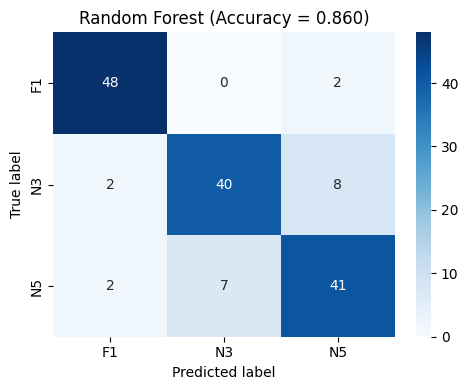

In [7]:
kfold = KFold(n_splits=5, shuffle=True, random_state=127)

random_forest = RandomForestClassifier(n_estimators=50, random_state=127, n_jobs=-1)

scores = cross_val_score(random_forest, X_train, y_train, cv=kfold, scoring="accuracy")
print(f"Mean CV accuracy: {scores.mean():.3f} ± {scores.std():.3f}")

random_forest.fit(X_train, y_train)
y_pred = random_forest.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Test accuracy: {accuracy:.3f}")

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Random Forest (Accuracy = {accuracy:.3f})")
plt.tight_layout()
plt.savefig(project_root / "results" / "confusion_matrix_RF_multiclass.png", dpi=300)
plt.show()

## Feedforward Neural Network

Same architecture as `02_LIBS_classification.ipynb` — two hidden layers with ReLU activation and dropout — with the output layer sized to the number of classes (4 instead of 2).

In [8]:
def build_model(input_dim, n_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(n_classes, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

### Five-fold cross-validation

In [9]:
X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy()
n_classes = len(np.unique(y_train_np))

kfold = KFold(n_splits=5, shuffle=True, random_state=127)
fold_accuracies = []

for train_idx, val_idx in kfold.split(X_train_np):
    X_train_fold, X_val_fold = X_train_np[train_idx], X_train_np[val_idx]
    y_train_fold, y_val_fold = y_train_np[train_idx], y_train_np[val_idx]

    model = build_model(X_train_np.shape[1], n_classes)
    early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=100, batch_size=32, verbose=0, callbacks=[early_stop],
    )
    _, accuracy = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    fold_accuracies.append(accuracy)

print(f"Mean CV accuracy: {np.mean(fold_accuracies):.3f} ± {np.std(fold_accuracies):.3f}")

I0000 00:00:1788450502.209801 1436518 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-09-03 12:48:22.210281: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2343] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Mean CV accuracy: 0.971 ± 0.011


### Final model training

In [10]:
model = build_model(X_train.shape[1], n_classes)
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100, batch_size=32,
    callbacks=[early_stop], verbose=1,
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3251 - loss: 1.1010 - val_accuracy: 0.3222 - val_loss: 1.0495
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3892 - loss: 1.0608 - val_accuracy: 0.4000 - val_loss: 1.0187
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4079 - loss: 1.0397 - val_accuracy: 0.5667 - val_loss: 0.9719
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4940 - loss: 1.0031 - val_accuracy: 0.5889 - val_loss: 0.9168
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5389 - loss: 0.9560 - val_accuracy: 0.5889 - val_loss: 0.8571
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5562 - loss: 0.9118 - val_accuracy: 0.6000 - val_loss: 0.8031
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5897 - loss: 0.8821 - val_accuracy: 0.6000 - val_loss: 0.7665
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6079 - loss: 0.8534 - val_accuracy: 0.6111 - 

### Learning curves

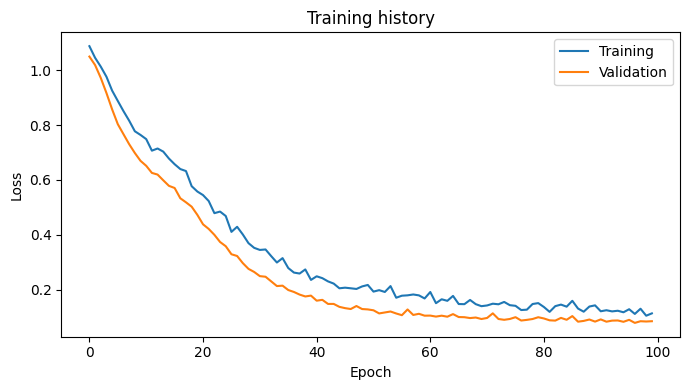

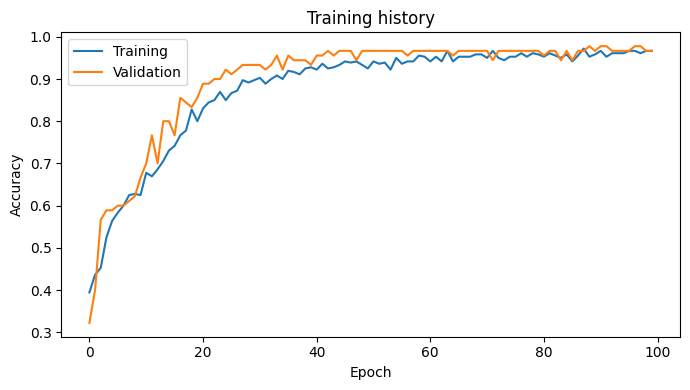

In [11]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training history")
plt.legend()
plt.tight_layout()
plt.savefig(project_root / "results" / "Training_History_Loss_multiclass.png", dpi=300)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training history")
plt.legend()
plt.tight_layout()
plt.savefig(project_root / "results" / "Training_History_Accuracy_multiclass.png", dpi=300)
plt.show()

### Performance on the independent test set

Test accuracy: 0.913
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


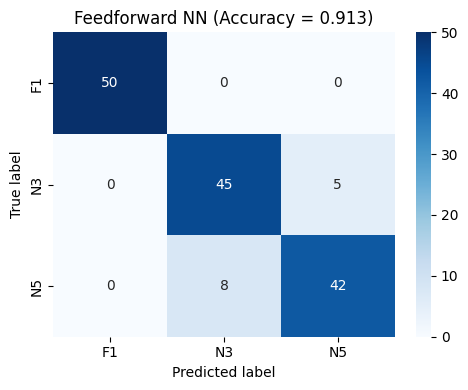

In [12]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {accuracy:.3f}")

y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Feedforward NN (Accuracy = {accuracy:.3f})")
plt.tight_layout()
plt.savefig(project_root / "results" / "CM_NN_multiclass.png", dpi=300)
plt.show()

## Generalization across different bones of the same individual

As in `02_LIBS_classification.ipynb`, the previous evaluation only measures performance on spectra from specimens seen during training. Here each classifier is tested on one additional, never-seen bone specimen per individual.

_Training_

| Individual | Specimen used for training |
|---|---|
| F1 | muestra 1 |
| N3 | muestra 2 |
| N5 | muestra 1 |

_Generalization test_ (never seen during training)

| Individual | Held-out specimen |
|---|---|
| F1 | muestra 2 |
| N3 | muestra 1 |
| N5 | muestra 2 |

In [13]:
def load_specimen(experiments, feature_columns):
    df_specimen = condense_and_join.join_data(path_to_raw, experiments, seg=seg)
    df_specimen = condense_and_join.normalize_dataframe(df_specimen)
    df_specimen = condense_and_join.select_region(df_specimen, xmin=250, xmax=400)
    return df_specimen[feature_columns]


generalization_specimens = {
    "F1": (["F1-muestra 2-log_09ago.24_113401-ascii"], 0),
    "N3": ([
        "N3-muestra1-log_24jul.24_152442-ascii",
        "N3-muestra1-log_24jul.24_152958-ascii",
        "N3-muestra1-log_24jul.24_153633-ascii",
    ], 1),
    "N5": ([
        "N5-muestra 2-log_08ago.24_110232-ascii",
        "N5-muestra 2-log_08ago.24_110914-ascii",
    ], 2),
}

# These held-out specimens are not part of `selected_experiments` above,
# so they haven't been condensed to CSV yet.
holdout_experiments = [exp for experiments, _ in generalization_specimens.values() for exp in experiments]
condense_and_join.condense(holdout_experiments, path_to_raw, seg, test=False)

/home/redmati/Documents/ML-LIBS/spectral-classification-toolkit/raw_data/F1-muestra 2-log_09ago.24_113401-ascii
/home/redmati/Documents/ML-LIBS/spectral-classification-toolkit/raw_data/N3-muestra1-log_24jul.24_152442-ascii
/home/redmati/Documents/ML-LIBS/spectral-classification-toolkit/raw_data/N3-muestra1-log_24jul.24_152958-ascii
/home/redmati/Documents/ML-LIBS/spectral-classification-toolkit/raw_data/N3-muestra1-log_24jul.24_153633-ascii
/home/redmati/Documents/ML-LIBS/spectral-classification-toolkit/raw_data/N5-muestra 2-log_08ago.24_110232-ascii
/home/redmati/Documents/ML-LIBS/spectral-classification-toolkit/raw_data/N5-muestra 2-log_08ago.24_110914-ascii


In [14]:
y_true_gen, y_pred_gen_nn, y_pred_gen_rf = [], [], []
generalization_results = []

for specimen_name, (experiments, true_label) in generalization_specimens.items():
    X_new = load_specimen(experiments, X_train.columns)

    nn_pred = np.argmax(model.predict(X_new, verbose=0), axis=1)
    rf_pred = random_forest.predict(X_new)

    y_true_gen += [true_label] * len(X_new)
    y_pred_gen_nn += list(nn_pred)
    y_pred_gen_rf += list(rf_pred)

    generalization_results.append({
        "specimen": specimen_name,
        "n_spectra": len(X_new),
        "expected_class": true_label,
        "rf_accuracy": accuracy_score([true_label] * len(X_new), rf_pred),
        "nn_accuracy": accuracy_score([true_label] * len(X_new), nn_pred),
    })

generalization_df = pd.DataFrame(generalization_results)
generalization_df

,specimen,n_spectra,expected_class,rf_accuracy,nn_accuracy
0,F1,100,0,0.870000,0.940
1,N3,300,1,0.736667,0.940
2,N5,200,2,0.845000,0.825


### Generalization confusion matrix

Pooling the four held-out specimens together shows not just per-individual accuracy but *which* individuals get confused with which.

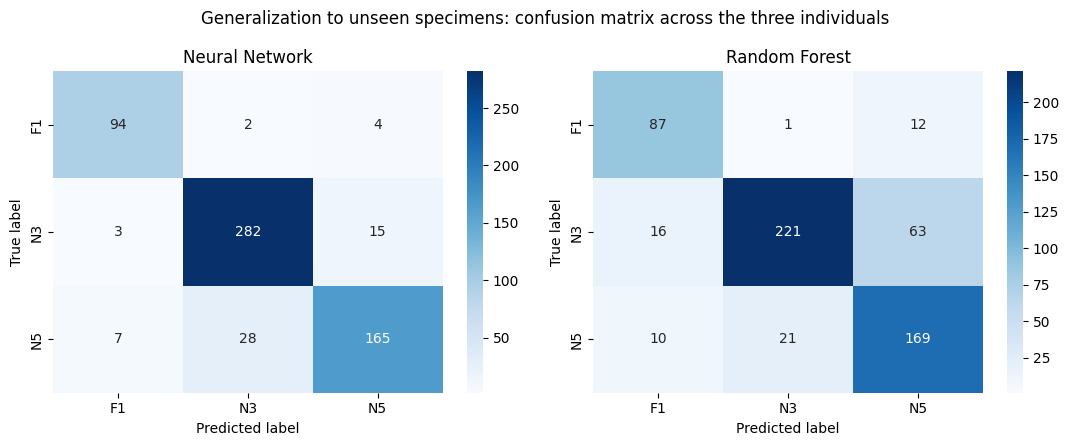

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm_nn_gen = confusion_matrix(y_true_gen, y_pred_gen_nn, labels=[0, 1, 2])
cm_rf_gen = confusion_matrix(y_true_gen, y_pred_gen_rf, labels=[0, 1, 2])

sns.heatmap(cm_nn_gen, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title("Neural Network")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")

sns.heatmap(cm_rf_gen, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")

fig.suptitle("Generalization to unseen specimens: confusion matrix across the three individuals")
plt.tight_layout()
plt.savefig(project_root / "results" / "CM_generalization_multiclass.png", dpi=300)
plt.show()

### Discussion

Dropping N1 and restricting to the three individuals whose specimens are internally consistent (F1, N3, N5) leaves the ordinary test-split performance essentially unchanged from the 4-class run — Random Forest 0.860 (5-fold CV: 0.896 ± 0.033), the neural network 0.913 (CV: 0.971 ± 0.011) — which makes sense: N1 wasn't a particularly *hard* class to separate on same-specimen data, it was a class whose held-out specimen didn't resemble its own training specimen.

**Generalization is where dropping N1 pays off, exactly as predicted from `01_EDA.ipynb`'s CV analysis:**

| Individual | RF (4-class) | RF (3-class) | NN (4-class) | NN (3-class) |
|---|---|---|---|---|
| F1 | 0.85 | 0.87 | 0.98 | 0.94 |
| N3 | 0.72 | 0.74 | 0.92 | 0.94 |
| N5 | 0.40 | **0.845** | 0.465 | **0.825** |

F1 and N3 barely move — confirming their earlier generalization numbers weren't an artifact of the 4-class setup. **N5 improves dramatically**: Random Forest goes from 0.40 to 0.845, the neural network from 0.465 to 0.825, both roughly doubling. The pooled confusion matrix confirms this isn't noise: in the 4-class run, ~50% of N5's held-out spectra were misclassified as N1 specifically; with N1 removed, N5's held-out spectra land correctly (165/200 NN, 169/200 RF), with most of the remaining confusion now going the other way, N5 ↔ N3 (28/200 NN predicted as N3; RF confuses N3 and N5 in both directions, 63/300 and 21/200).

This is consistent with `01_EDA.ipynb`'s CV finding rather than a coincidence: N1 was the one individual whose two bone specimens disagree with each other (within-individual CV ≈ 0.22) almost as much as raw shot noise (CV ≈ 0.25), and more than the typical between-individual difference (CV ≈ 0.13). Because N1's training specimen and held-out specimen weren't consistent representatives of "N1" to begin with, the model learned a decision boundary shaped partly by N1's idiosyncratic training spectra — and N5, whose own between-specimen CV (0.09–0.11) is unremarkable, still ended up on the wrong side of it in the 4-class model. Removing the noisy class removed that distortion. The practical implication for this dataset: an individual's spectral consistency across its own physical specimens (measurable directly from raw data, without training any model) is a useful screening check before including that individual in a classification study, `01_EDA.ipynb`'s Level 2 CV is exactly that check, and it correctly flagged the individual that would go on to hurt generalization here.